# Classification Metrics Deep Dive — Beyond Accuracy

This notebook demonstrates:

- Why accuracy fails under imbalance
- How precision, recall, and F1 behave
- How decision threshold changes model behavior
- ROC vs Precision-Recall curves
- Cost-sensitive evaluation

Goal:
Think in terms of decision impact, not just metric values.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_curve,
    roc_auc_score,
    precision_recall_curve,
    average_precision_score
)

np.random.seed(42)

In [2]:
X, y = make_classification(
    n_samples=2000,
    n_features=5,
    n_informative=3,
    weights=[0.95, 0.05],  # 5% positive class
    random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

pd.Series(y).value_counts(normalize=True)

0    0.9445
1    0.0555
Name: proportion, dtype: float64

Only ~5% of samples are positive.

A model predicting all zeros would achieve ~95% accuracy.

This demonstrates why accuracy can be misleading.

In [11]:
model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]


In [4]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

pd.DataFrame({
    "Accuracy": [accuracy],
    "Precision": [precision],
    "Recall": [recall],
    "F1": [f1]
})

,Accuracy,Precision,Recall,F1
0,0.965,0.928571,0.393939,0.553191


Accuracy may appear high due to majority class dominance.

Precision tells us:
Of predicted positives, how many were correct?

Recall tells us:
Of actual positives, how many were detected?

F1 balances both.

In [5]:
cm = confusion_matrix(y_test, y_pred)
cm

array([[566,   1],
       [ 20,  13]])

Confusion Matrix:

|            | Pred 0 | Pred 1 |
|------------|--------|--------|
| Actual 0   | TN     | FP     |
| Actual 1   | FN     | TP     |

All metrics derive from this matrix.

Default classification threshold:

$$
P(y=1|x) > 0.5
$$

This is arbitrary.

Lowering threshold increases recall.
Raising threshold increases precision.

In [6]:
def evaluate_threshold(threshold):
    preds = (y_prob >= threshold).astype(int)
    
    return {
        "Threshold": threshold,
        "Precision": precision_score(y_test, preds),
        "Recall": recall_score(y_test, preds),
        "F1": f1_score(y_test, preds)
    }

results = pd.DataFrame([
    evaluate_threshold(t)
    for t in [0.1, 0.3, 0.5, 0.7, 0.9]
])

results

,Threshold,Precision,Recall,F1
0,0.1,0.418182,0.696970,0.522727
1,0.3,0.818182,0.545455,0.654545
2,0.5,0.928571,0.393939,0.553191
3,0.7,1.000000,0.303030,0.465116
4,0.9,1.000000,0.242424,0.390244


As threshold decreases:

- Recall increases
- Precision decreases

Threshold selection must align with business cost.

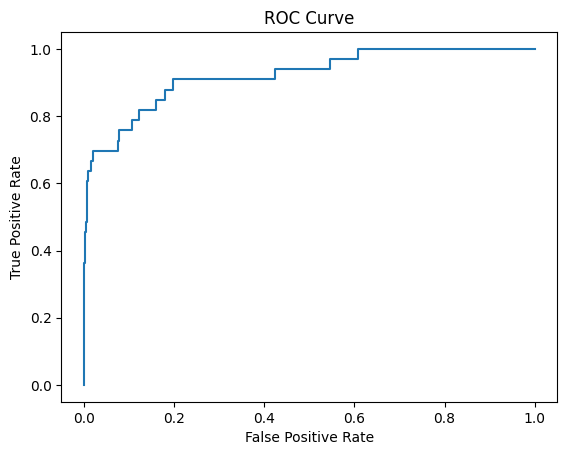

0.9217038105926996

In [7]:
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = roc_auc_score(y_test, y_prob)

plt.figure()
plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

roc_auc

ROC plots:

TPR vs FPR

AUC measures ranking ability.

However, ROC can look optimistic
when positive class is rare.

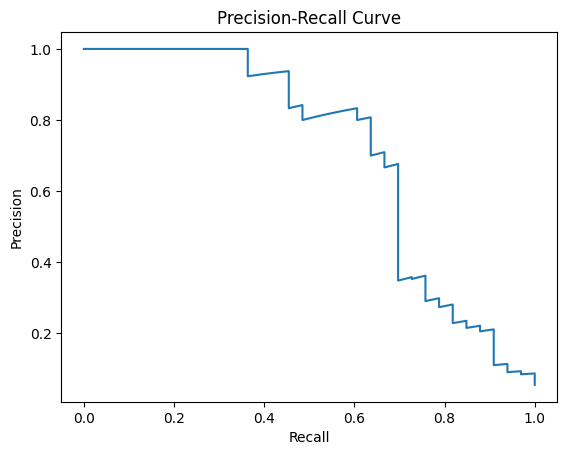

0.7086630249849482

In [8]:
precision_curve, recall_curve, _ = precision_recall_curve(y_test, y_prob)
avg_precision = average_precision_score(y_test, y_prob)

plt.figure()
plt.plot(recall_curve, precision_curve)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

avg_precision

PR curve focuses on positive class performance.

For imbalanced datasets,
PR is often more informative than ROC.

Assume:

- Cost of FP = 1
- Cost of FN = 10

False negatives are 10x more expensive.

We simulate total cost at different thresholds.

In [9]:
def compute_cost(threshold):
    preds = (y_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, preds).ravel()
    
    cost = fp * 1 + fn * 10
    return {"Threshold": threshold, "Total Cost": cost}

cost_results = pd.DataFrame([
    compute_cost(t)
    for t in np.linspace(0.1, 0.9, 9)
])

cost_results

,Threshold,Total Cost
0,0.1,132
1,0.2,113
2,0.3,154
3,0.4,181
4,0.5,201
5,0.6,210
6,0.7,230
7,0.8,230
8,0.9,250


Lowest cost threshold is not necessarily 0.5.

Metric optimization must reflect domain cost structure.